In [5]:
import pandas as pd
df = pd.read_csv(r"C:\Users\nikim\Desktop\data_final_ökonometrie_projekt.csv")
df.head()

,land,jahr,hpi,arbeitslosenrate,inflation,leitzinsen
0,Belgium,2015,100.00,8.7,100.00,0.05
1,Belgium,2016,102.33,7.9,101.77,0.00
2,Belgium,2017,105.95,7.2,104.03,0.00
3,Belgium,2018,109.15,6.0,106.44,0.00
4,Belgium,2019,113.23,5.5,107.77,0.00


In [9]:
df.groupby("land").mean(numeric_only=True)

,jahr,hpi,arbeitslosenrate,inflation,leitzinsen
land,,,,,
Austria,2019.5,134.564,5.58,112.219,1.02
Belgium,2019.5,118.412,6.42,112.080,1.02
Croatia,2019.5,134.728,8.80,109.028,1.02
Cyprus,2019.5,105.764,8.65,104.259,1.02
Estonia,2019.5,143.744,6.16,119.000,1.02
Finland,2019.5,104.569,7.91,106.996,1.02
France,2019.5,115.351,8.51,108.134,1.02
Germany,2019.5,132.300,3.52,110.060,1.02
Ireland,2019.5,138.945,6.10,105.640,1.02


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

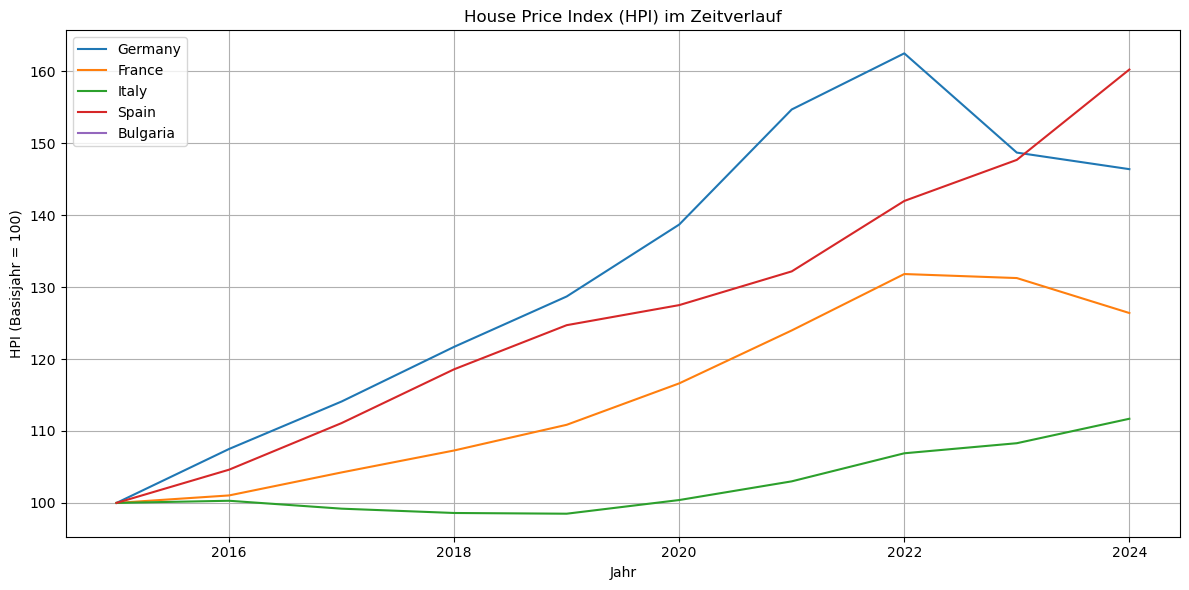

In [17]:
länder = ['Germany', 'France', 'Italy', 'Spain', 'Bulgaria'] 

plt.figure(figsize=(12, 6))
for land in länder:
    daten = df[df['land'] == land]
    plt.plot(daten['jahr'], daten['hpi'], label=land)
    
plt.title('House Price Index (HPI) im Zeitverlauf')
plt.xlabel('Jahr')
plt.ylabel('HPI (Basisjahr = 100)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



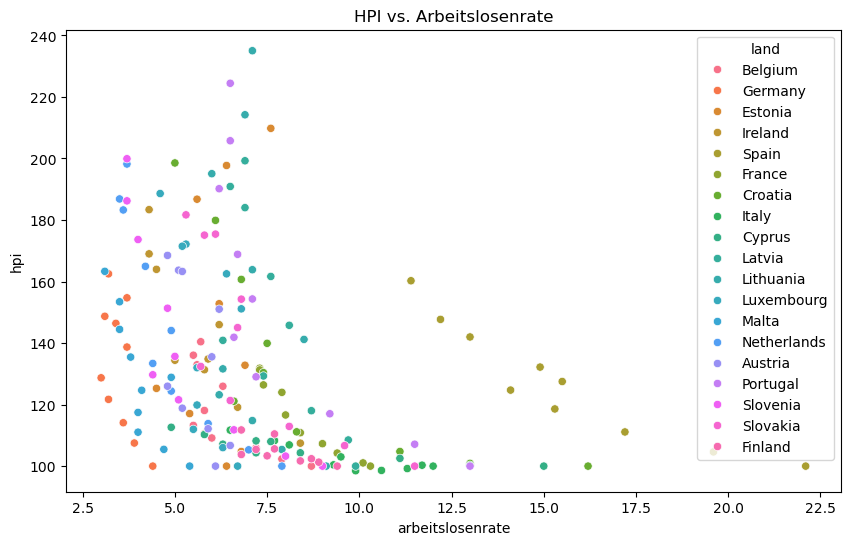

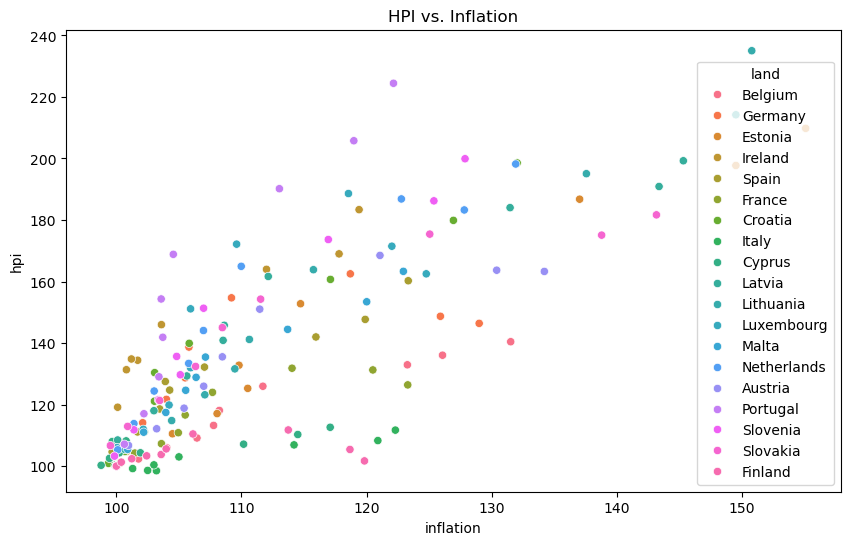

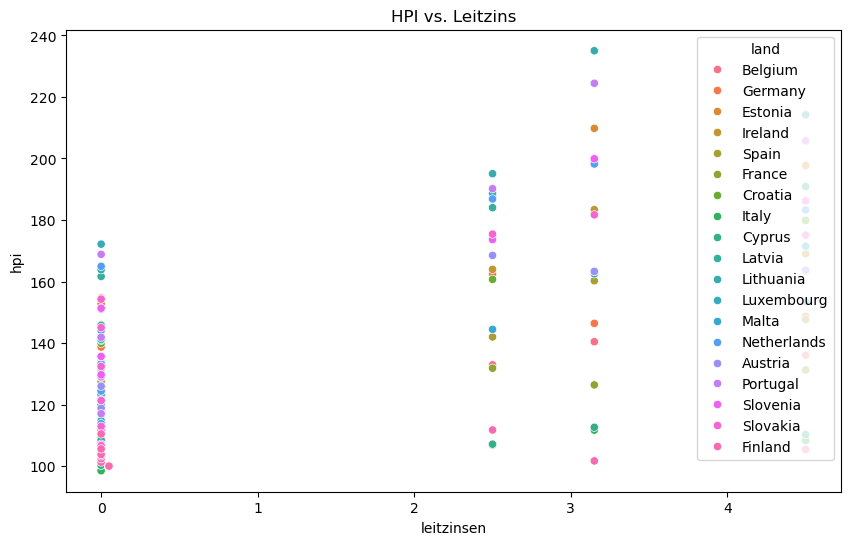

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='arbeitslosenrate', y='hpi', hue='land')
plt.title('HPI vs. Arbeitslosenrate')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='inflation', y='hpi', hue='land')
plt.title('HPI vs. Inflation')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='leitzinsen', y='hpi', hue='land')
plt.title('HPI vs. Leitzins')
plt.show()

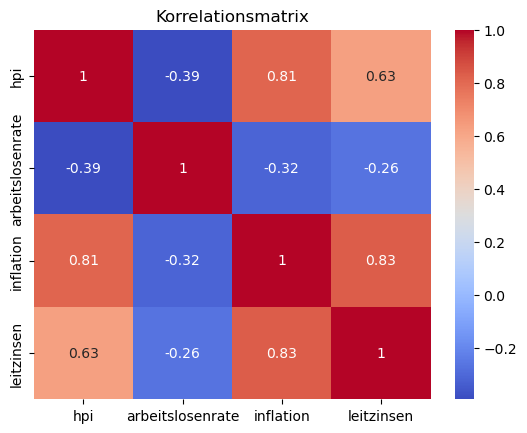

In [25]:
corr_df = df[['hpi', 'arbeitslosenrate', 'inflation', 'leitzinsen']].corr()
sns.heatmap(corr_df, annot=True, cmap='coolwarm')
plt.title('Korrelationsmatrix')
plt.show()

In [27]:
import statsmodels.api as sm

In [29]:
df = pd.read_csv("C:/Users/nikim/Desktop/data_final_ökonometrie_projekt.csv")


print(df.columns)


X = df[['inflation', 'arbeitslosenrate', 'leitzinsen']]
y = df['hpi']


X = sm.add_constant(X)

model = sm.OLS(y, X).fit()


print(model.summary())

Index(['land', 'jahr', 'hpi', 'arbeitslosenrate', 'inflation', 'leitzinsen'], dtype='object')
                            OLS Regression Results                            
Dep. Variable:                    hpi   R-squared:                       0.689
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     137.5
Date:                Thu, 01 May 2025   Prob (F-statistic):           5.63e-47
Time:                        01:25:11   Log-Likelihood:                -813.29
No. Observations:                 190   AIC:                             1635.
Df Residuals:                     186   BIC:                             1648.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

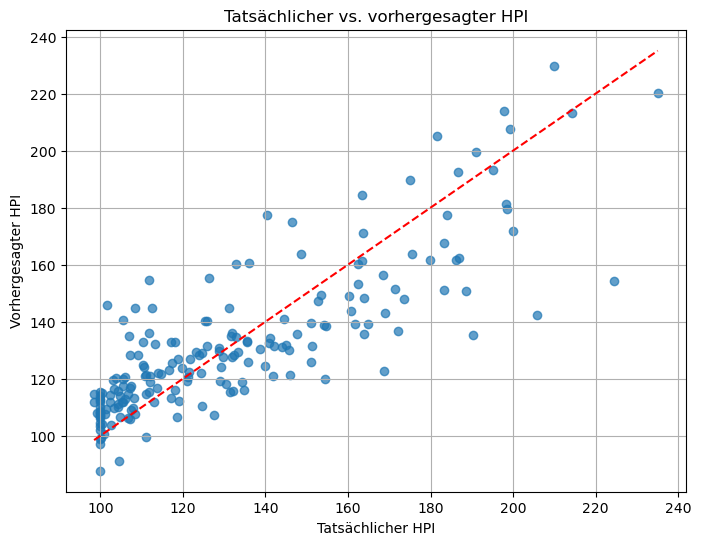

In [33]:
import matplotlib.pyplot as plt
y_pred = model.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 45°-Linie
plt.xlabel("Tatsächlicher HPI")
plt.ylabel("Vorhergesagter HPI")
plt.title("Tatsächlicher vs. vorhergesagter HPI")
plt.grid(True)
plt.show()

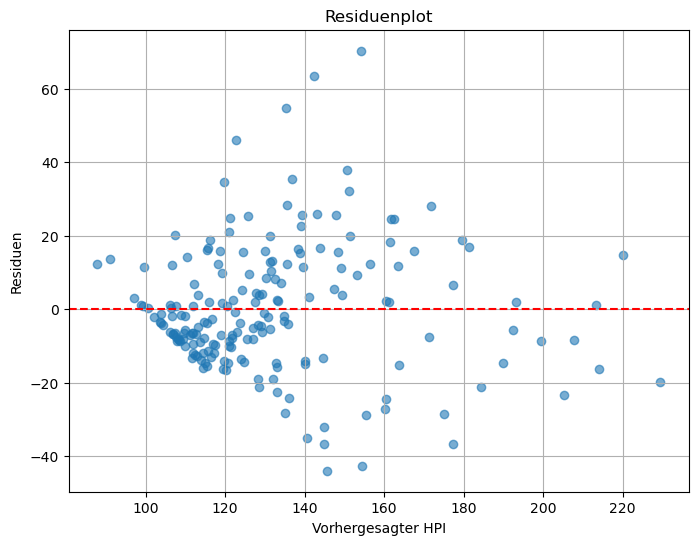

In [35]:
residuals = y - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Vorhergesagter HPI")
plt.ylabel("Residuen")
plt.title("Residuenplot")
plt.grid(True)
plt.show()

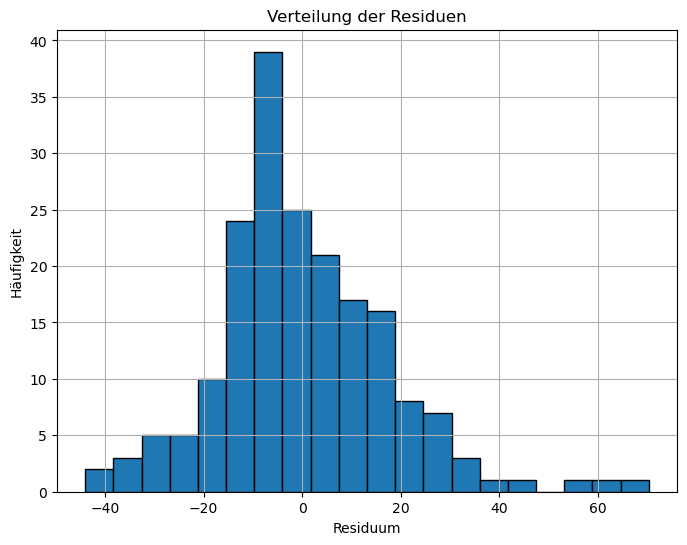

In [37]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, edgecolor='black')
plt.title("Verteilung der Residuen")
plt.xlabel("Residuum")
plt.ylabel("Häufigkeit")
plt.grid(True)
plt.show()

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Daten laden
df = pd.read_csv("C:/Users/nikim/Desktop/data_final_ökonometrie_projekt.csv")

# Features und Ziel definieren
X = df[['inflation', 'arbeitslosenrate', 'leitzinsen']]
y = df['hpi']

# Daten aufteilen in Trainings- und Testdaten (z. B. 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modell erstellen
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Vorhersage
y_pred = model.predict(X_test)

# Auswertung
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Mean Squared Error: 287.82497893894686
R² Score: 0.6872128242340093


In [41]:
import numpy as np

neue_daten = pd.DataFrame({
    'inflation': [5.2],
    'arbeitslosenrate': [6.1],
    'leitzinsen': [3.5]
})

vorhersage = model.predict(neue_daten)
print("Vorhergesagter HPI:", round(vorhersage[0], 2))

Vorhergesagter HPI: 103.11


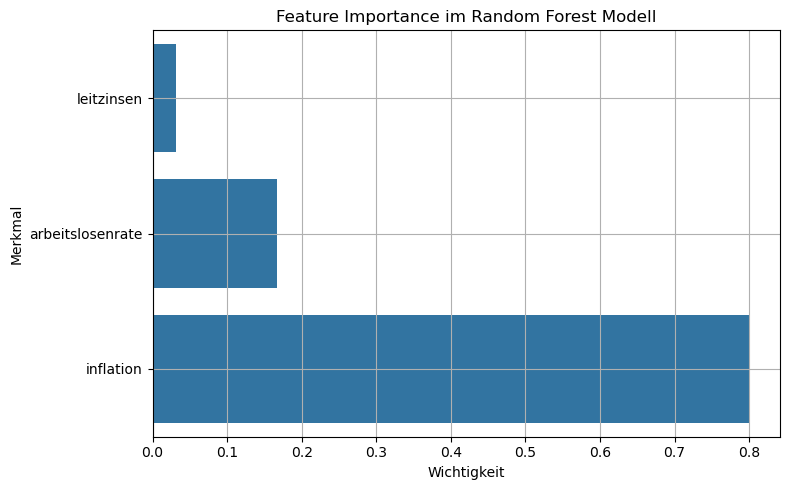

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ======================
# 1. Daten laden
# ======================
df = pd.read_csv("C:/Users/nikim/Desktop/data_final_ökonometrie_projekt.csv")

X = df[['inflation', 'arbeitslosenrate', 'leitzinsen']]
y = df['hpi']

# ======================
# 2. Modell trainieren
# ======================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ======================
# 3. Feature Importance Plot
# ======================
importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=features[indices])
plt.title('Feature Importance im Random Forest Modell')
plt.xlabel('Wichtigkeit')
plt.ylabel('Merkmal')
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:

import streamlit as st
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# CSV-Datei laden
df = pd.read_csv("C:\\Users\\nikim\\Desktop\\HIP_Projekt+ml.ipynb")

# Features und Ziel
X = df[['inflation', 'arbeitslosenrate', 'leitzinsen']]
y = df['hpi']

# Modell trainieren
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Titel
st.title("🏡 HPI Prognose-App")

# Eingabefelder
inflation = st.slider("Inflation (%)", min_value=0.0, max_value=20.0, value=5.0, step=0.1)
arbeitslosenrate = st.slider("Arbeitslosenrate (%)", min_value=0.0, max_value=30.0, value=6.0, step=0.1)
leitzinsen = st.slider("Leitzins (%)", min_value=-2.0, max_value=20.0, value=3.0, step=0.1)

# Vorhersage berechnen
input_df = pd.DataFrame({
    'inflation': [inflation],
    'arbeitslosenrate': [arbeitslosenrate],
    'leitzinsen': [leitzinsen]
})

prediction = model.predict(input_df)[0]
st.success(f"📈 Vorhergesagter HPI: {round(prediction, 2)}")

ParserError: Error tokenizing data. C error: Expected 1 fields in line 4, saw 2
